# 1. Pipeline de visión paso a paso

Recorrido de la Fase 1 sobre una imagen: de la foto al JSON que recibe el solver. Cada paso llama a las funciones de `src/vision/` (el notebook no reimplementa nada). Detalles y decisiones en `docs/fase1_vision.md`.

Por defecto usa una imagen sintética: una grilla **irregular** fotografiada sobre un fondo de color, que muestra todos los pasos. Para usar otra imagen, cambiar `IMAGE` por su ruta.

In [1]:
import os, sys
from pathlib import Path
# ejecutar desde la raíz del repositorio para que funcionen los imports de src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show(*imgs, titles=None, size=4.5):
    fig, axes = plt.subplots(1, len(imgs), figsize=(size * len(imgs), size))
    axes = np.atleast_1d(axes)
    for k, (ax, im) in enumerate(zip(axes, imgs)):
        if im.ndim == 3:
            ax.imshow(im[..., ::-1])            # BGR (OpenCV) -> RGB
        else:
            ax.imshow(im, cmap="gray")
        ax.set_title(titles[k] if titles else "", fontsize=10, loc="left")
        ax.axis("off")
    plt.tight_layout(); plt.show()

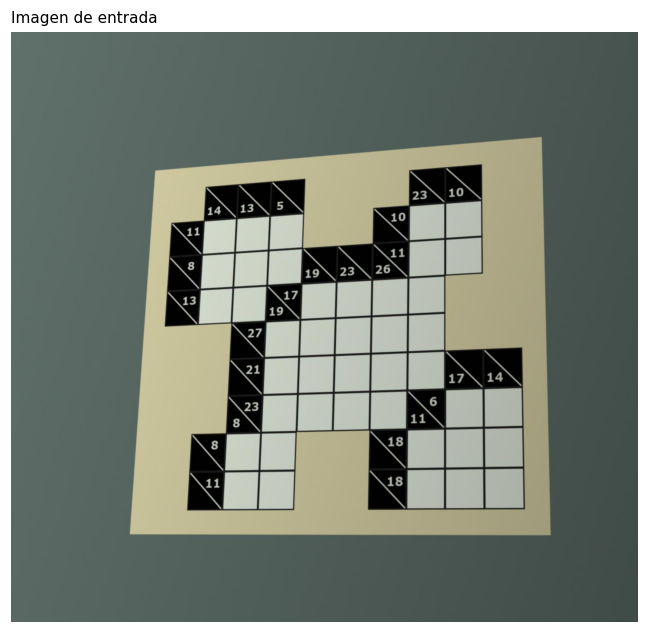

In [2]:
from src.eval.render import FONTS_TEST, available_fonts, make_sample
from src.vision.preprocess import normalize_size, enhance, binarize, to_gray

IMAGE = None            # p. ej. "data/examples/ejemplo_negro_foto.jpg"
if IMAGE:
    original = cv2.imdecode(np.fromfile(IMAGE, np.uint8), cv2.IMREAD_COLOR); truth = None
else:
    original, truth = make_sample(3, 1003, available_fonts(FONTS_TEST))
show(original, titles=["Imagen de entrada"], size=6)

## Pasos 1–2: normalización, CLAHE y umbral adaptativo

El umbral adaptativo (y no Otsu global) tolera el gradiente de iluminación y las sombras. Queda invertido: líneas y tinta en blanco.

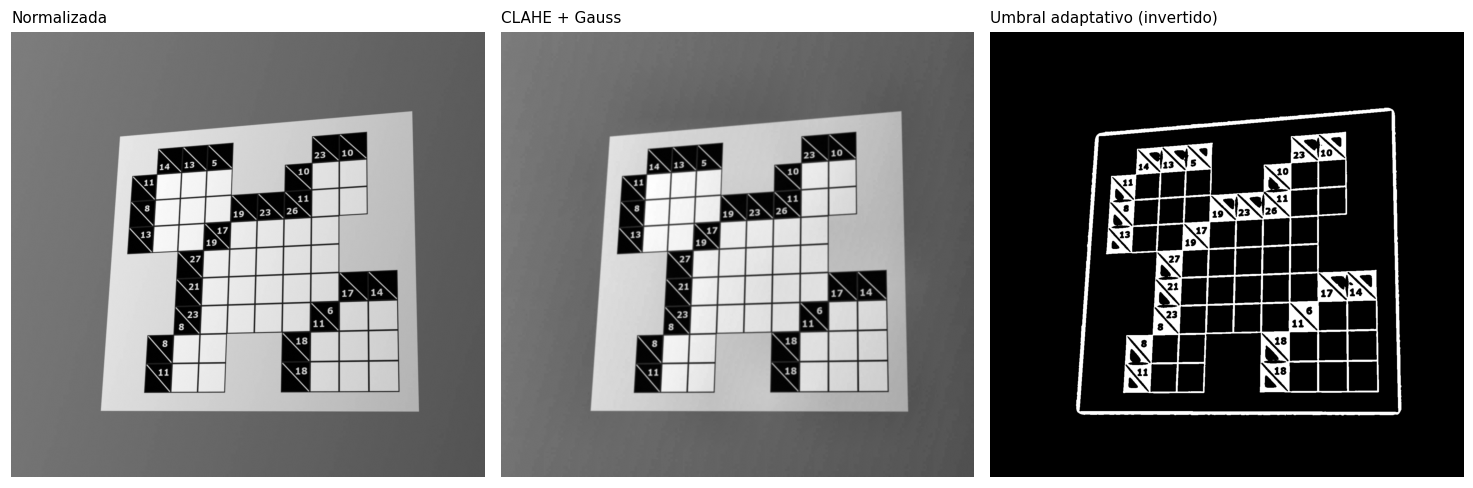

In [3]:
gray, scale = normalize_size(to_gray(original))
enhanced = enhance(gray)
binary = binarize(enhanced)
show(gray, enhanced, binary, titles=["Normalizada", "CLAHE + Gauss", "Umbral adaptativo (invertido)"])

## Pasos 3–4: candidatos de rectificación

No se asume que la grilla tenga un borde rectangular propio (puede ser irregular, tener márgenes o un marco, o tocar el borde de la imagen). Se prueban varios cuadriláteros:

- contornos cuadriláteros grandes (borde de la grilla, hoja, marco),
- `lines`: las líneas más externas de la propia grilla (Hough),
- `image`: la imagen completa,
- `fallback`: extremos del contorno mayor (método del paper).

Cada uno se rectifica y se mide la nitidez de la retícula que produce; entre los aceptables gana el que explica más celdas. Luego se rectifica de nuevo solo la extensión de la retícula (`+ajuste`), para ganar resolución.

quad      retícula  9 x 10  nitidez 0.688


lines     retícula  9 x 6   nitidez 0.547


image     retícula 13 x 14  nitidez 0.278


fallback  retícula  9 x 10  nitidez 0.688



elegido: quad+ajuste -> 9 x 10


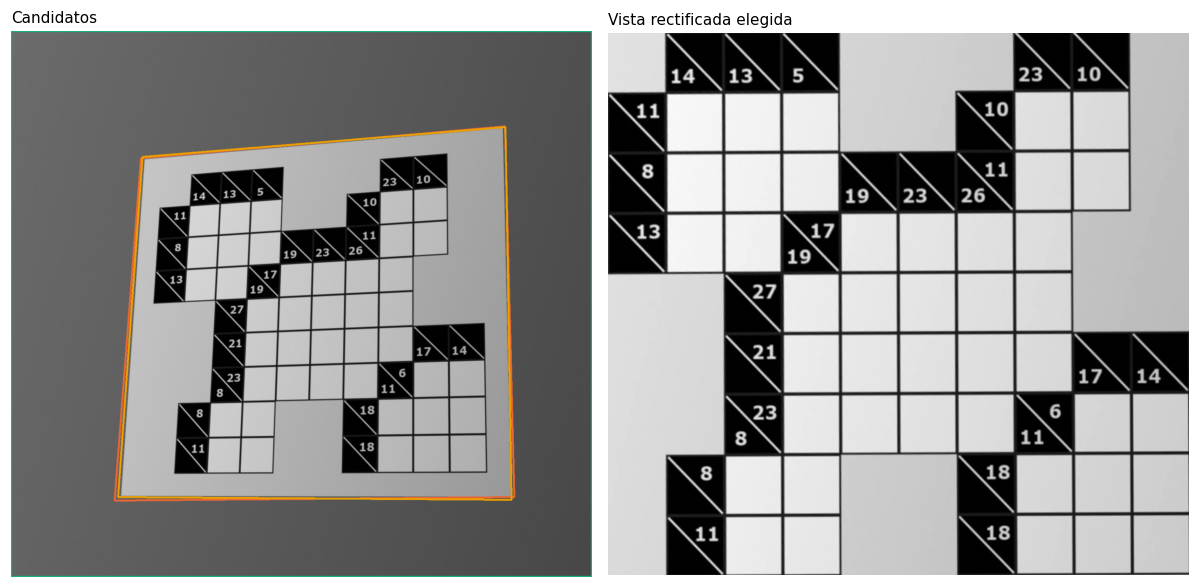

In [4]:
from src.vision.locate import candidate_quads, rectify, warp
from src.vision.grid import detect_grid

cands = candidate_quads(binary)
vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
colors = [(214, 120, 42), (52, 104, 235), (122, 175, 27), (0, 161, 237), (164, 123, 232), (72, 73, 227)]
for (q, m), col in zip(cands, colors):
    cv2.polylines(vis, [q.astype(int)], True, col, 4)
    w, _ = warp(gray, q)
    g = detect_grid(w)
    print(f"{m:<9} retícula {g.rows:>2} x {g.cols:<2}  nitidez {g.score:.3f}")

rect = rectify(gray, binary)
print("\nelegido:", rect.method, f"-> {rect.grid.rows} x {rect.grid.cols}")
show(vis, rect.warped, titles=["Candidatos", "Vista rectificada elegida"], size=5.5)

## Paso 5: retícula (período, fase y extensión)

Una apertura morfológica con núcleo de ~0.6 celdas deja solo las líneas de la grilla (desaparecen dígitos y diagonales); la suma por columnas da picos en las líneas. El período sale de un "peine": para cada período candidato se mide el perfil en ancla + k·p (probando como ancla las líneas más fuertes). Los múltiplos del período real puntúan igual de alto, por eso se elige el menor período con puntuación cercana al máximo. Luego se siguen las líneas desde la más fuerte, tolerando hasta 3 líneas invisibles seguidas (entre celdas negras).

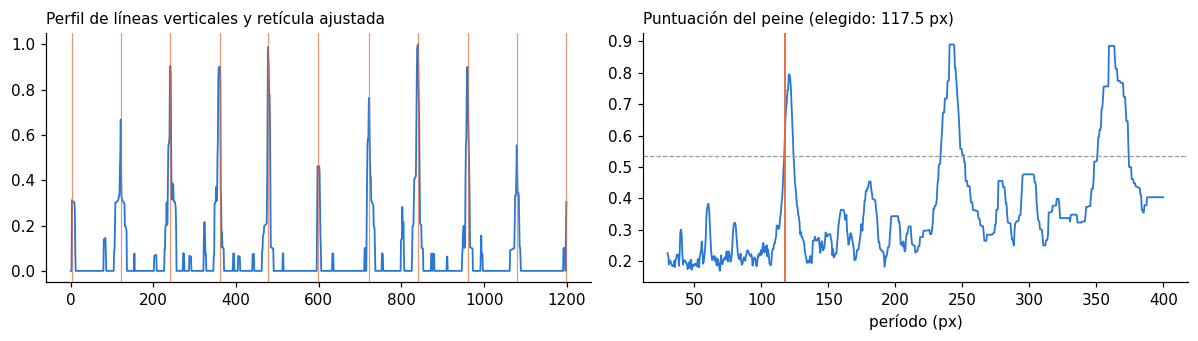

retícula cruda: 9 x 10 (puede incluir celdas de margen; se recortan en el paso 7)


In [5]:
from src.vision.grid import line_profiles, period_scores, estimate_period, COMB_RATIO
from src.vision.preprocess import binarize as binarize_

warped, grid = rect.warped, rect.grid
bw = binarize_(cv2.GaussianBlur(warped, (3, 3), 0), block_frac=1 / 25, c=5)
_, px0 = line_profiles(warped, binary=bw)
cell_w = estimate_period(px0)
_, px = line_profiles(warped, k_h=int(0.6 * cell_w), k_v=int(0.6 * cell_w), binary=bw)
periods, scores = period_scores(px)
p = estimate_period(px)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(px, color="#2a78d6", lw=1.2)
for x in grid.xs:
    axes[0].axvline(x, color="#eb6834", lw=0.8, alpha=0.7)
axes[0].set_title("Perfil de líneas verticales y retícula ajustada", fontsize=10, loc="left")
axes[1].plot(periods, scores, color="#2a78d6", lw=1.2)
axes[1].axhline(COMB_RATIO * scores.max(), color="#999", ls="--", lw=0.8)
axes[1].axvline(p, color="#eb6834", lw=1.2)
axes[1].set_xlabel("período (px)")
axes[1].set_title(f"Puntuación del peine (elegido: {p:.1f} px)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()
print(f"retícula cruda: {grid.rows} x {grid.cols} (puede incluir celdas de margen; se recortan en el paso 7)")

## Pasos 6–7: blanca, pista o fuera del puzzle

Medidas por celda: brillo relativo a la iluminación estimada, contraste de la diagonal, **saturación** (un fondo de color no es papel) y **cierre** (fracción de lados con línea). Una celda es:

- **pista** si es oscura o tiene diagonal,
- **blanca** si es clara como el papel, sin color, sin diagonal y cerrada por líneas,
- **fuera** en otro caso (fondo, márgenes).

Después, reglas del Kakuro: todo tramo de blancas empieza tras una pista, y se recortan los bordes sin nada del puzzle. Por último, la **estructura** decide qué pistas existen (suma horizontal si la celda de la derecha es blanca, vertical si la de abajo lo es).

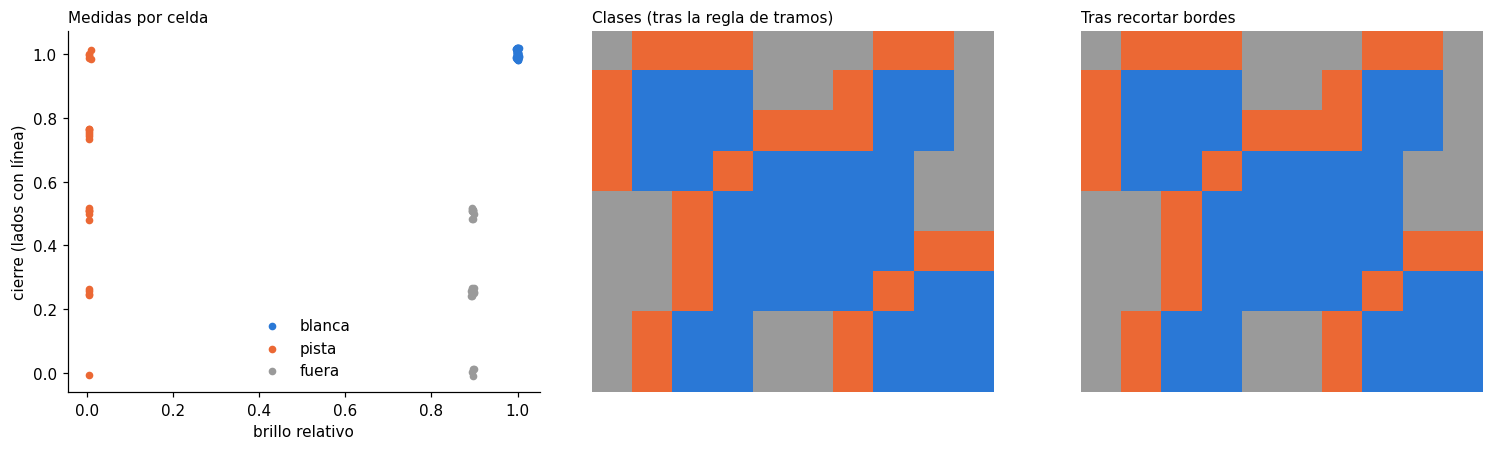

grilla final: 9 x 10


In [6]:
from src.vision.cells import cell_features, classify, enforce_runs, trim, infer_clues, WHITE, CLUE, OUTSIDE
from src.vision.grid import Grid

color = cv2.resize(original, (gray.shape[1], gray.shape[0])) if original.ndim == 3 else None
color_w = cv2.warpPerspective(color, rect.H, (warped.shape[1], warped.shape[0])) if color is not None else None
feats = cell_features(warped, grid, color_w)
kind0 = classify(feats)
kind1 = enforce_runs(kind0)
kind, rs, cs = trim(kind1)

names = {WHITE: "blanca", CLUE: "pista", OUTSIDE: "fuera"}
cols_ = {WHITE: "#2a78d6", CLUE: "#eb6834", OUTSIDE: "#9a9a9a"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for kd, m in cols_.items():
    sel = kind0 == kd
    axes[0].scatter(feats.relative[sel], feats.enclosure[sel] + np.random.uniform(-0.02, 0.02, sel.sum()),
                    s=16, color=m, label=names[kd])
axes[0].set_xlabel("brillo relativo"); axes[0].set_ylabel("cierre (lados con línea)")
axes[0].legend(frameon=False); axes[0].set_title("Medidas por celda", fontsize=10, loc="left")
cmap = plt.matplotlib.colors.ListedColormap([cols_[WHITE], cols_[CLUE], cols_[OUTSIDE]])
for ax, k, t in ((axes[1], kind1, "Clases (tras la regla de tramos)"), (axes[2], kind, "Tras recortar bordes")):
    ax.imshow(k, cmap=cmap, vmin=0, vmax=2); ax.set_title(t, fontsize=10, loc="left"); ax.axis("off")
plt.tight_layout(); plt.show()

grid = Grid(grid.xs[cs.start:cs.stop + 1], grid.ys[rs.start:rs.stop + 1], grid.score_rows, grid.score_cols)
structure = infer_clues(kind)
print(f"grilla final: {grid.rows} x {grid.cols}")

## Pasos 8–10: triángulos, dígitos y CNN

Cada pista se recorta con una máscara triangular y se normaliza la polaridad (trazo claro sobre fondo oscuro). Si un componente es ambiguo (un dígito ancho o dos pegados), se generan varias hipótesis de segmentación y decide la CNN junto con los rangos de suma válidos. Cada dígito, centrado en 28×28, pasa por la CNN.

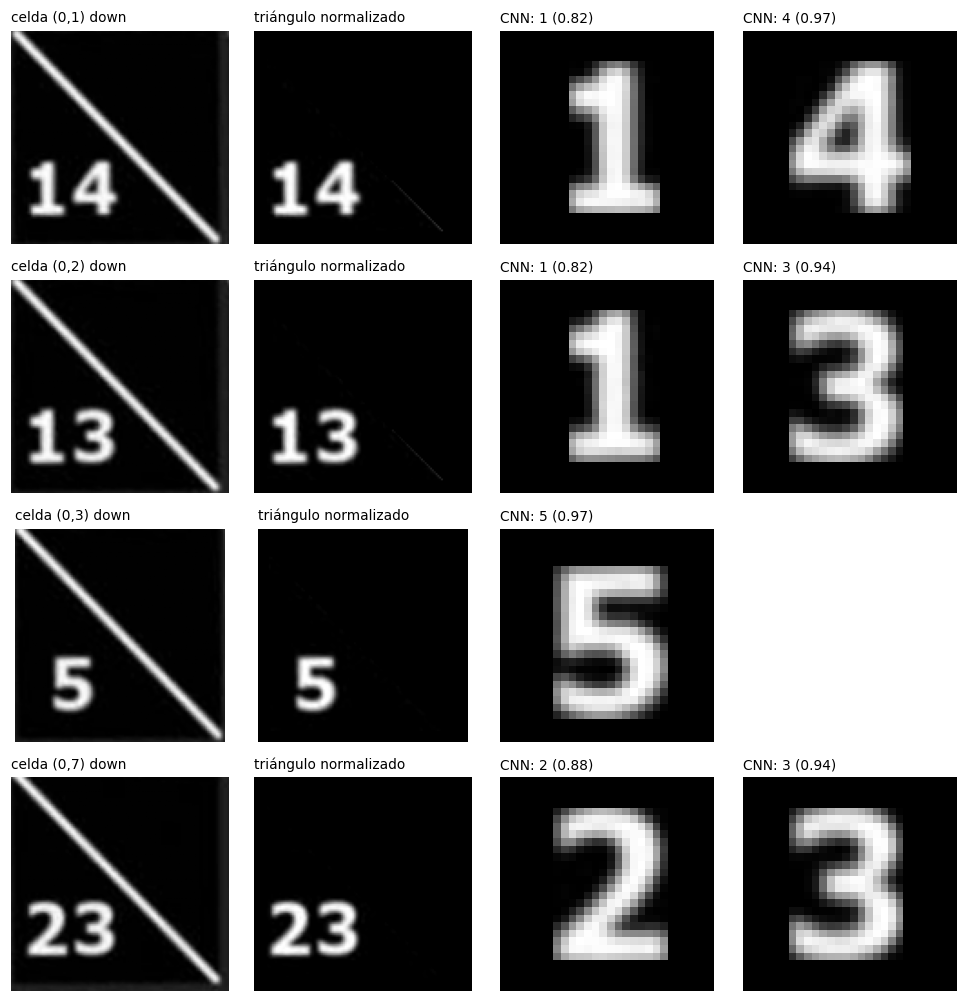

In [7]:
from src.vision.digits import extract_region, segment_digits, to_canvas
from src.vision.ocr_cnn import DigitReader

reader = DigitReader()
examples = [(i, j, d) for i in range(grid.rows) for j in range(grid.cols)
            if structure[i][j]["type"] == "clue" for d in ("right", "down") if structure[i][j][d] is not None][:4]
fig, axes = plt.subplots(len(examples), 4, figsize=(9, 2.3 * len(examples)))
for row, (i, j, d) in zip(np.atleast_2d(axes), examples):
    x0, y0, x1, y1 = grid.cell_box(i, j)
    norm, mask = extract_region(warped, grid.cell_box(i, j), d)
    canv = [to_canvas(norm, b) for b in segment_digits(norm, mask)]
    probs = reader.probabilities(canv)
    row[0].imshow(warped[y0:y1, x0:x1], cmap="gray"); row[0].set_title(f"celda ({i},{j}) {d}", fontsize=9, loc="left")
    row[1].imshow(norm, cmap="gray"); row[1].set_title("triángulo normalizado", fontsize=9, loc="left")
    for k in range(2):
        if k < len(canv):
            row[2 + k].imshow(canv[k], cmap="gray")
            row[2 + k].set_title(f"CNN: {probs[k].argmax()} ({probs[k].max():.2f})", fontsize=9, loc="left")
    for ax in row:
        ax.axis("off")
plt.tight_layout(); plt.show()

## Pasos 11–12: validación y JSON

`process_gray` ejecuta todos los pasos anteriores, valida cada número con las reglas de Kakuro y genera el JSON (formato de la sección 3 de `docs/fase1_vision.md`). Con el JSON, el solver (Fase 2) resuelve el puzzle.

In [8]:
import json
from src.vision.pipeline import process_gray
from src.solver.__main__ import render
from src.solver.parse import parse_puzzle
from src.solver.solve import solve_puzzle

puzzle = process_gray(original, reader).puzzle
result = solve_puzzle(parse_puzzle(puzzle))
print(render(parse_puzzle(puzzle), result))
print(f"\n{result.status}  única: {result.unique}  pistas inciertas: {len(puzzle['uncertain_clues'])}")
if truth is not None:
    same = [[c["type"] for c in r] for r in puzzle["grid"]] == [[c["type"] for c in r] for r in truth["grid"]]
    clues_ok = all(puzzle["grid"][i][j] == truth["grid"][i][j]
                   for i in range(truth["rows"]) for j in range(truth["cols"])) if same else False
    print("¿estructura igual a la etiqueta real?", same, "| ¿pistas iguales?", clues_ok)

  ###  |  14\  |  13\  |   5\  |  ###  |  ###  |  ###  |  23\  |  10\  |  ###  
  \11  |   4   |   6   |   1   |  ###  |  ###  |  \10  |   6   |   4   |  ###  
   \8  |   1   |   3   |   4   |  19\  |  23\  | 26\11 |   5   |   6   |  ###  
  \13  |   9   |   4   | 19\17 |   1   |   3   |   4   |   9   |  ###  |  ###  
  ###  |  ###  |  \27  |   5   |   7   |   4   |   9   |   2   |  ###  |  ###  
  ###  |  ###  |  \21  |   2   |   6   |   7   |   5   |   1   |  17\  |  14\  
  ###  |  ###  |  8\23 |   1   |   5   |   9   |   8   |  11\6 |   4   |   2   
  ###  |   \8  |   5   |   3   |  ###  |  ###  |  \18  |   8   |   6   |   4   
  ###  |  \11  |   3   |   8   |  ###  |  ###  |  \18  |   3   |   7   |   8   

OPTIMAL  única: False  pistas inciertas: 2
¿estructura igual a la etiqueta real? True | ¿pistas iguales? True
